# 1. Librairies et paramètres

In [1]:
import smtplib
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from email.mime.base import MIMEBase
from email import encoders
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import zipfile
import time
from config import SENDER_EMAIL, EMAIL_PASSWORD, SMTP_SERVER, SMTP_PORT, MAX_EMAIL_SIZE

In [2]:
# année à traiter
year = "2026"

In [7]:
sender_email = SENDER_EMAIL
email_password = EMAIL_PASSWORD
smtp_server = SMTP_SERVER
smtp_port = SMTP_PORT
max_email_size = MAX_EMAIL_SIZE

# 2. Définition des fonction 

In [8]:
def get_images_from_dossard(dossard: int):
    """
    Récupère les chemins des images associées à un dossard spécifique.  
    """

    # parcours de toutes les galeries
    results_repertory = Path('Results') / year
    galeries = [d for d in os.listdir(results_repertory) if os.path.isdir(os.path.join(results_repertory, d))]

    images_path = []

    for galerie in galeries:

        galerie_path = Path(results_repertory, galerie)
        files = sorted([f for f in os.listdir(galerie_path) if f.lower().endswith("post_process.csv")])
        
        if len(files) > 0:
            file_name = files[0]
            file_path = os.path.join(galerie_path, file_name)

            df_result = pd.read_csv(file_path)

            # Vérifier dans toutes les colonnes Dossard_x si le dossard est présent
            mask = df_result.drop(columns=["file"]).eq(dossard).any(axis=1)

            # nom complet de l'image
            galerie_image_path = Path('Images') / year / galerie
            matched_files = df_result.loc[mask, "file"].apply(lambda f: galerie_image_path / f).tolist()
            images_path.extend(matched_files)

    return images_path

In [4]:
def create_zip_archive(images_list, output_zip_path):
    """
    Crée une archive ZIP contenant les images spécifiées.
    """
    
    with zipfile.ZipFile(output_zip_path, 'w', compression=zipfile.ZIP_DEFLATED) as zipf:
        for img_path in images_list:
            zipf.write(img_path, arcname=os.path.basename(img_path))  # arcname = nom dans le zip
    return output_zip_path

In [9]:
def write_and_send_email(
    receiver_email: str, 
    dossard_photos_link: list, 
    total_mail_count: int, 
    subject_prefix="Trail des Sources de l'Yvette - Photos"):
    """
    Envoie les photos associées à un dossard par email, en découpant les mails si nécessaire.
    """

    # Découpage en mails selon la taille
    current_batch = []
    current_size = 0
    mail_count = 1
    total_mail_count += 1

    for img_path in dossard_photos_link:
        if not os.path.isfile(img_path):
            print(f"⚠️ Fichier non trouvé : {img_path}")
            continue

        file_size = os.path.getsize(img_path)
        # Si ajouter cette image dépasse la limite, envoyer le mail actuel et commencer un nouveau batch
        if current_size + file_size > MAX_EMAIL_SIZE and current_batch:
            send_email_batch(sender_email, receiver_email, current_batch, subject_prefix, mail_count)
            mail_count += 1
            total_mail_count += 1
            current_batch = []
            current_size = 0

        current_batch.append(img_path)
        current_size += file_size

    # Envoyer le dernier batch
    if current_batch:
        send_email_batch(sender_email , receiver_email, current_batch, subject_prefix, mail_count)

    return total_mail_count

In [10]:
def send_email_batch(sender_email, receiver_email, files_list, subject_prefix, batch_number):
    """
    Envoie un email avec les fichiers spécifiés en pièce jointe.
    """

    # mot de passe

    subject = f"{subject_prefix} ({batch_number})" if batch_number > 1 else subject_prefix
    if batch_number == 1:
        body_html = """
        Bonjour, \n\n

        <p>Nous avons le plaisir de vous adresser ce(s) quelque(s) photo(s) de vous prises lors de notre
        6ème édition du Trail des Sources de l’Yvette.
        Vous pouvez aussi découvrir d’autre photos de l’édition dans la rubrique 
        <a href='https://www.tsy-levis78.fr/galerie-photos2026'>Galerie photos 2026 | TSY Trail des Sources de l'Yvette</a> de notre site.</p>

        <p>Merci encore pour votre participation. Nous vous disons à l’année prochaine, le dimanche 20 septembre 2026.</p>

        <p>Les TSYlers</p>

        <p>PS : la reconnaissance de votre dossard ayant été faite par algorithme, merci par avance pour votre compréhension en cas d’erreur.</p>
        """
    else:
        body_html = """ 
        Bonjour, \n\n
        <p>La suite des images de votre dossard :</p>
        """

    msg = MIMEMultipart()
    msg["From"] = sender_email
    msg["To"] = receiver_email
    msg["Subject"] = subject
    msg.attach(MIMEText(body_html, "html"))


    # Ajouter les fichiers
    for filename in files_list:
        with open(filename, "rb") as f:
            part = MIMEBase("application", "octet-stream")
            part.set_payload(f.read())
            encoders.encode_base64(part)
            part.add_header(
                "Content-Disposition",
                f"attachment; filename={os.path.basename(filename)}"
            )
            msg.attach(part)

    # Envoi via Gmail
    with smtplib.SMTP(smtp_server, smtp_port) as server:
        server.starttls()
        server.login(sender_email, email_password)
        server.send_message(msg)

    print(f"📩 Mail envoyé avec succès ! Batch {batch_number}, {len(files_list)} fichiers.")

In [11]:
def send_mail_to_everyone(year='2026', start=None, end=None, total_mail_count=0):
    """
    Envoie les photos associées à chaque dossard par email, en découpant les mails si nécessaire.
    """ 
    
    # Lecture du fichier correspondance dossard - email
    dossard_email_file_name = "dossard_email.csv"
    dossard_email_file_path = Path('Data') / year / dossard_email_file_name

    df_dossard_email = pd.read_csv(
        dossard_email_file_path,
        sep=';',                # séparateur point-virgule
        encoding='latin1'       # ou 'iso-8859-1' (équivalent)
    )

    if not start:
        start = 0
    if not end:
        end = len(df_dossard_email)

    # Couples prénom/nom à ignorer (tout en minuscule)
    skip_list = {
        ("martin", "donze"),
        ("antonio", "godoy pellini"),
        ("fabien", "michel"),
        ("martin", "halbourg")
    }

    # parcours de chaque ligne entre start et end
    for idx, row in df_dossard_email.iloc[start:end].iterrows():
        
        # info de la personne
        mail ="lemerle.xavier@gmail.com"  # mail = row["Mail"]
        prenom = row["Prenom"].lower()
        nom = row["Nom"].lower()
        dossard_str = row["Dossard"]

        if (prenom, nom) in skip_list:
            print(f"⏭️ Mail ignoré pour {prenom.title()} {nom.title()} (dossard {dossard_str})")
            continue

        if pd.isna(mail) or str(mail).strip() == "":
            print(f"Pas de mail renseigné pour dossard {dossard_str}")
            continue

        # conversion du dossart en int
        try:
            dossard = int(dossard_str)
        except ValueError:
            print(f"⚠️ Dossard invalide à la ligne {idx} : {dossard_str}")
            continue

        # récupération des photos associés
        dossard_photos_link = get_images_from_dossard(dossard)

        # envoie des mails 
        if len(dossard_photos_link) >= 1:
            print(f"Dossard {dossard}, envoie de(s) {len(dossard_photos_link)} photo(s) à {mail}...")
            total_mail_count = write_and_send_email(mail, dossard_photos_link, total_mail_count)
            print(f"Nombre total de mail envoyés : {total_mail_count} (index {idx})")

            # pause de 10sec
            time.sleep(10)
        else: 
            print(f"Dossard {dossard}, pas de photo trouvée.")

    return total_mail_count

# 3. Envoie des mails

**Test d'affichage des photos d'un dossard**

Images\2026\Galerie_test\IMG_4848.JPG


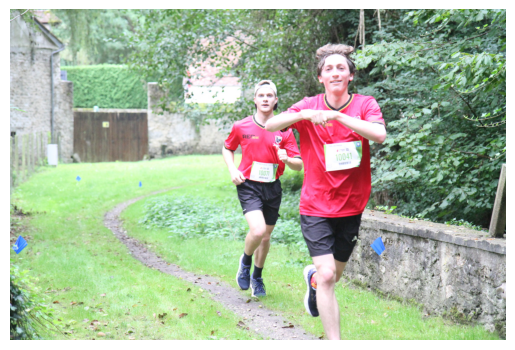

In [12]:
images_path = get_images_from_dossard(10071)

for image_path in images_path:
    print(image_path)

    image = mpimg.imread(image_path)

    if image is None: 
        print(f"Impossible de lire {images_path}")
        continue

    plt.imshow(image)
    plt.axis('off')  # Masquer les axes
    plt.show()

**Envoie de tous les mails**

In [13]:
total_mail_count = send_mail_to_everyone(
    year="2026", 
    start=None, 
    end=None, 
    total_mail_count=0
)

Dossard 10071, envoie de(s) 1 photo(s) à lemerle.xavier@gmail.com...
📩 Mail envoyé avec succès ! Batch 1, 1 fichiers.
Nombre total de mail envoyés : 1 (index 0)
